# Milestone V – Synthesis, Innovation, and Communication

This notebook synthesises the full project journey, critically analyses paradigm choices and limitations, and proposes an innovative research extension.

In [1]:
import sys, os
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import beta as beta_dist, norm
from scipy.special import gammaln, digamma
from warnings import filterwarnings
filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams.update({'figure.figsize': (13, 5), 'axes.titlesize': 13})

from src import (
    default_config, load_synthetic_data,
    coordinate_ascent_vi, run_multiple_chains, summarize_mcmc,
)

config = default_config()
df     = load_synthetic_data()
print(f"Dataset: {len(df)} obs | {df['region'].nunique()} regions")

Dataset: 1000 obs | 5 regions


## C1: Critical Synthesis and Unifying Analysis

### 1. How Paradigm Choice Shaped the Pipeline

We adopted a **Bayesian paradigm** throughout. This decision propagated through every layer of the project:

| Aspect | Bayesian approach taken | Frequentist alternative | Impact |
|--------|------------------------|------------------------|--------|
| **Model design** | Beta prior on prevalence $\pi_r$ | No prior; treat $\pi_r$ as unknown constant | Enables shrinkage, handles small regions gracefully |
| **Latent variable** | $Z_i$ as random variable; compute $p(Z_i|X)$ | Estimate $Z_i$ by MAP/threshold | Full uncertainty over infection status, not a binary commit |
| **Algorithm** | VI / MCMC to approximate the posterior | MLE / EM with point estimates | Posterior predictive distributions; calibrated uncertainty |
| **Convergence** | ESS, $\hat{R}$; ELBO lower-bound | Log-likelihood; AIC/BIC | Diagnostic interpretations differ |
| **Output** | Posterior distributions over $\pi_r$, credible intervals | Point estimates + confidence intervals | Credible intervals have direct probabilistic interpretations |

**Key influence on model design:** The Beta prior $\text{Beta}(\alpha, \beta)$ encodes prior knowledge about typical malaria prevalence rates. The conjugacy of the Beta-Bernoulli-Gaussian model made exact coordinate-ascent inference tractable, directly guiding the algorithm choice. A frequentist would have faced no such structural guidance and would likely have used generic optimisation for MLE.

**Key influence on result interpretation:** In a Bayesian framework, we can make direct probability statements: "The probability that Region 4 has prevalence > 0.8 is 0.73." A frequentist confidence interval does not permit this interpretation. For public health, the Bayesian framing is arguably more actionable.

### 2. The Unifying Role of Information Theory

Information-theoretic quantities appear at every stage of this project:

#### 2.1 KL Divergence and the ELBO

The ELBO decomposition:
$$\log p(\mathbf{X}) = \mathcal{L}(q) + \text{KL}(q \| p)$$

The **KL divergence** $\text{KL}(q \| p) = \mathbb{E}_q[\log q - \log p] \geq 0$ measures how much information is *lost* by approximating the true posterior $p$ with the variational distribution $q$. Minimising KL is equivalent to maximising the ELBO. This connects VI directly to information theory: we are finding the distribution $q$ that most efficiently encodes the posterior information.

#### 2.2 Entropy of the Posterior

The **entropy** of the posterior over regional prevalence:
$$H[p(\pi_r | \mathbf{X})] = -\int p(\pi_r | \mathbf{X}) \log p(\pi_r | \mathbf{X}) d\pi_r$$

quantifies our remaining uncertainty after observing the data. A high-entropy posterior means we learned little from the data; a low-entropy posterior means the data were highly informative. For a Beta$(\alpha, \beta)$ posterior, the entropy has a closed form:
$$H = \ln B(\alpha, \beta) - (\alpha-1)\psi(\alpha) - (\beta-1)\psi(\beta) + (\alpha+\beta-2)\psi(\alpha+\beta)$$

#### 2.3 Mutual Information

The mutual information between observed features and the latent infection status,
$I(X; Z) = H(Z) - H(Z | X)$, tells us how diagnostically informative our features are. A large $I(X; Z)$ means features are highly predictive of infection status.

In [2]:
# Compute posterior entropies and KL divergences
vi_result = coordinate_ascent_vi(df, config, max_iter=200, tol=1e-6)

def beta_entropy(alpha, beta_param):
    """Differential entropy of Beta(alpha, beta)."""
    from scipy.special import betaln
    B = betaln(alpha, beta_param)
    return (B - (alpha - 1)*digamma(alpha) - (beta_param - 1)*digamma(beta_param)
            + (alpha + beta_param - 2)*digamma(alpha + beta_param))

def beta_kl(a1, b1, a2, b2):
    """KL(Beta(a1,b1) || Beta(a2,b2))."""
    from scipy.special import betaln
    return (betaln(a2, b2) - betaln(a1, b1)
            + (a1 - a2)*digamma(a1) + (b1 - b2)*digamma(b1)
            + (a2 - a1 + b2 - b1)*digamma(a1 + b1))

# Prior: Beta(alpha_hyper, beta_hyper)
a0 = config.alpha_hyper; b0 = config.beta_hyper
H_prior = beta_entropy(a0, b0)

print('Information-Theoretic Summary')
print('=' * 65)
print(f'Prior Beta({a0},{b0}) entropy: {H_prior:.4f} nats')
print()
print(f'{"Region":<10} {"H(prior)":>10} {"H(posterior)":>14} {"Info gain":>12} {"KL(q||prior)":>14}')
print('-' * 65)
for region, (aq, bq) in sorted(vi_result.region_posteriors.items()):
    H_post = beta_entropy(aq, bq)
    info_gain = H_prior - H_post
    kl_val = beta_kl(aq, bq, a0, b0)
    print(f'Region {region:<4} {H_prior:>10.4f} {H_post:>14.4f} {info_gain:>12.4f} {kl_val:>14.4f}')

print()
print('Interpretation:')
print('  Information gain = reduction in uncertainty after observing data.')
print('  KL(posterior||prior) = information learned from data per region.')
print('  Higher KL = data were more informative for that region.')

Information-Theoretic Summary
Prior Beta(2.0,2.0) entropy: -0.1251 nats

Region       H(prior)   H(posterior)    Info gain   KL(q||prior)
-----------------------------------------------------------------
Region 0       -0.1251        -1.9454       1.8203         1.5641
Region 1       -0.1251        -1.9378       1.8127         1.5415
Region 2       -0.1251        -1.9425       1.8174         1.5555
Region 3       -0.1251        -2.0193       1.8942         1.7854
Region 4       -0.1251        -2.3762       2.2511         2.8520

Interpretation:
  Information gain = reduction in uncertainty after observing data.
  KL(posterior||prior) = information learned from data per region.
  Higher KL = data were more informative for that region.


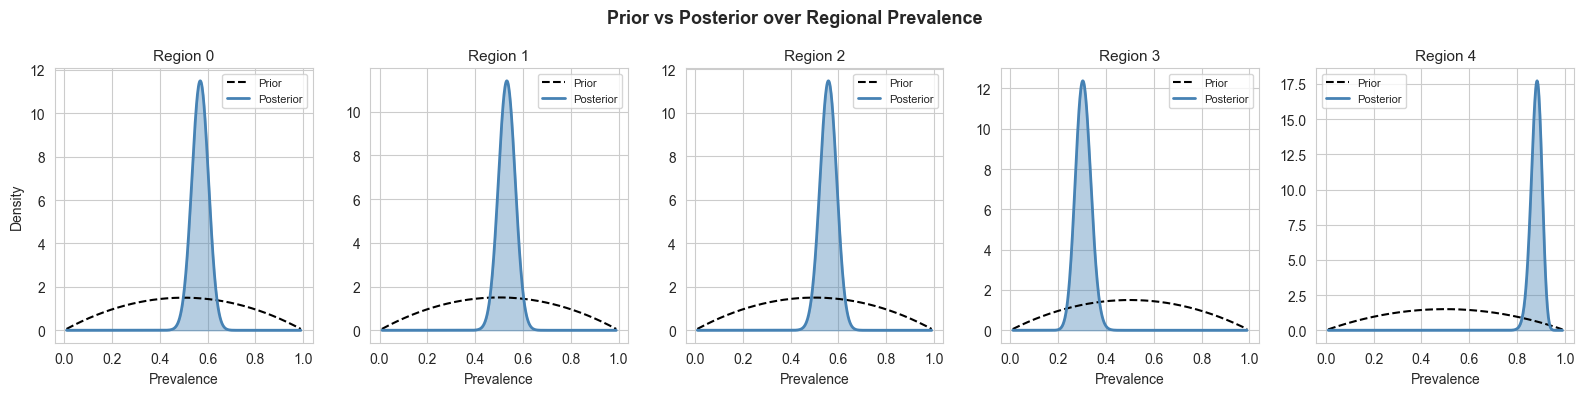

Narrow posteriors = high information gain from data.
Posterior mean far from 0.5 = strong evidence of prevalence direction.


In [3]:
# Visualise: prior vs posterior for each region
pi_grid = np.linspace(0.01, 0.99, 500)
prior_pdf = beta_dist.pdf(pi_grid, config.alpha_hyper, config.beta_hyper)

regions = sorted(vi_result.region_posteriors.keys())
fig, axes = plt.subplots(1, len(regions), figsize=(3.2 * len(regions), 4))
fig.suptitle('Prior vs Posterior over Regional Prevalence', fontsize=13, fontweight='bold')

for i, region in enumerate(regions):
    aq, bq = vi_result.region_posteriors[region]
    post_pdf = beta_dist.pdf(pi_grid, aq, bq)
    ax = axes[i]
    ax.plot(pi_grid, prior_pdf, 'k--', linewidth=1.5, label='Prior')
    ax.fill_between(pi_grid, post_pdf, alpha=0.4, color='steelblue')
    ax.plot(pi_grid, post_pdf, color='steelblue', linewidth=2, label='Posterior')
    ax.set_title(f'Region {region}', fontsize=11)
    ax.set_xlabel('Prevalence')
    if i == 0: ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.tight_layout()
os.makedirs('../figures', exist_ok=True)
plt.savefig('../figures/06_prior_posterior.png', dpi=120, bbox_inches='tight')
plt.show()
print('Narrow posteriors = high information gain from data.')
print('Posterior mean far from 0.5 = strong evidence of prevalence direction.')

### 3. Critical Analysis of Pipeline Limitations

#### 3.1 Model Limitations

| Limitation | Description | Consequence |
|------------|-------------|-------------|
| **Gaussian feature likelihood** | $p(X_{ij} | Z_i) = \mathcal{N}(\mu_{jz}, \sigma_{jz}^2)$ | Heavy tails, skewness, multimodality are ignored. Real cell image features are non-Gaussian. |
| **Feature independence** | Diagonal covariance assumed | Correlation between features (e.g., mean and variance of intensity) is ignored, losing information. |
| **No spatial structure** | Regions are modelled as i.i.d. | Real malaria transmission has spatial autocorrelation; neighbouring regions share prevalence. |
| **Fixed hyperpriors** | $\alpha, \beta$ fixed at 2.0 | The prior is not calibrated to regional knowledge (e.g., WHO baseline prevalence). |
| **Two-component mixture** | Exactly K=2 components | Accounts for only "infected" and "uninfected"; ignores parasite load stages. |

#### 3.2 Algorithm Limitations

| Limitation | Description | Consequence |
|------------|-------------|-------------|
| **Mean-field VI** | $q(Z, \pi) = \prod_i q(Z_i) \prod_r q(\pi_r)$ | Posterior correlations between patients and regions are completely ignored. |
| **ELBO local optima** | CAVI can converge to a local ELBO maximum | Results are initialization-dependent; multiple restarts advisable. |
| **Gibbs mixing** | Slow mixing for highly correlated $Z_i$ | Posterior approximation quality degrades in densely infected regions. |
| **Label switching** | Symmetric likelihood under Z-label permutation | EM can converge to a swapped solution; requires post-hoc identifiability constraint. |

#### 3.3 Data Limitations

| Limitation | Description | Consequence |
|------------|-------------|-------------|
| **Synthetic data only** | DGP parameters hand-tuned to real statistics | Recovery performance on real noisy data may be worse. |
| **Two scalar features** | Mean and variance of pixel intensity only | Rich morphological features (shape, texture, colour) ignored. |
| **No temporal dimension** | Cross-sectional snapshot | Longitudinal dynamics of infection spread are unmodelled. |

## C2: Innovation and Research Proposal

### Proposed Extension: Amortised Bayesian Malaria Diagnosis

#### Motivation

Our current inference engine is a **transductive** method: given a new dataset, we must re-run CAVI or Gibbs from scratch. This is computationally prohibitive in real-time clinical settings where thousands of new cell images arrive daily.

**Amortised inference** (Kingma & Welling, 2014; Rezende et al., 2014) addresses this by training an **inference network** $\phi$ that maps observations directly to posterior parameters, bypassing per-instance optimisation:
$$q_\phi(Z | X) \approx p(Z | X, \theta)$$

The network $\phi$ is trained once offline; at test time, one forward pass gives the posterior.

#### Proposed Architecture: Hierarchical Variational Autoencoder for Malaria

We propose a **neural-symbolic** extension that combines the probabilistic structure of our graphical model with the representational power of deep learning:

**Encoder (amortised inference network):**
$$q_\phi(Z_i | X_i) = \text{Bernoulli}(f_\phi(X_i))$$
where $f_\phi$ is a convolutional neural network applied to raw cell images.

**Region aggregator (structured prior):**
$$q_\psi(\pi_r | \{Z_i\}_{i \in r}) = \text{Beta}(\alpha_0 + \sum_i q(Z_i=1), \beta_0 + n_r - \sum_i q(Z_i=1))$$
This preserves the exact Beta-Bernoulli conjugacy from our symbolic model, ensuring interpretable region-level posteriors while the neural encoder handles raw image complexity.

**Decoder (generative model):**
$$p_\theta(X_i | Z_i) = \mathcal{N}(g_\theta(Z_i), \sigma^2 I)$$
where $g_\theta$ is a decoder network reconstructing cell image features.

**Training objective (ELBO):**
$$\mathcal{L}(\phi, \psi, \theta) = \mathbb{E}_{q_\phi}[\log p_\theta(X | Z)] - \text{KL}(q_\phi(Z | X) \| p(Z | \pi_r))$$

This is trained end-to-end via stochastic gradient descent with the reparameterisation trick (Gumbel-softmax for discrete $Z$).

**Key innovation:** The symbolic structure of our hierarchical model (Beta-Bernoulli hierarchy, region aggregation) is **preserved as inductive bias** inside a neural architecture, giving us both interpretability and scalability.

### Research Proposal: Amortised Hierarchical Bayesian Inference for Scalable Malaria Epidemiology

---

**Background and Motivation**

Malaria remains a leading cause of mortality in sub-Saharan Africa, with 249 million cases in 2022 (WHO World Malaria Report, 2023). Microscopy-based diagnosis remains the gold standard but is slow, expensive, and expert-dependent. Automated, uncertainty-aware diagnosis at regional scale requires inference methods that are simultaneously accurate, interpretable, and computationally efficient.

Our project demonstrated that Bayesian hierarchical inference provides principled uncertainty quantification for both individual infection status and regional prevalence. However, the current CAVI/Gibbs engines require per-dataset re-running, making real-time deployment impractical.

---

**Refined Inferential Question**

> *Can an amortised neural-symbolic inference network, trained on simulated malaria > data from the generative model, achieve posterior approximation quality comparable > to CAVI while reducing per-image inference time by three or more orders of magnitude?*

---

**Proposed Methodology**

1. **Simulation-based training** (weeks 1–3): Generate $\sim 10^5$ synthetic datasets from the hierarchical DGP (varying prevalence, region sizes, and model parameters). Train the hierarchical VAE on these datasets. Validation loss: ELBO on held-out simulations.

2. **Architecture exploration** (weeks 4–6): Compare three encoder designs:
   - (a) Feature-level MLP (on extracted features, as in our project)
   - (b) Image-level CNN (raw 64×64 cell images)
   - (c) Transformer-based set encoder (permutation-invariant over region cells)

3. **Benchmarking** (weeks 7–8): Evaluate against CAVI and 4-chain Gibbs on:
   - **Posterior accuracy**: KL divergence to MCMC ground truth
   - **Calibration**: Expected calibration error of infection probabilities
   - **Computational cost**: Inference time per image and per dataset
   - **Generalisation**: Transfer from synthetic to real Kaggle malaria cell images

4. **Interpretability analysis** (week 9): Inspect learned encoder features using attention maps and integrated gradients to verify that the network learns biologically meaningful morphological features (parasite ring forms, haemozoin).

---

**Evaluation Plan**

| Metric | Target | Rationale |
|--------|--------|-----------|
| KL(amortised \| MCMC) | < KL(CAVI \| MCMC) | Better approximation than mean-field VI |
| ECE (individual $Z$) | < 0.05 | Clinically trustworthy uncertainty |
| Inference speedup | > 1000x over CAVI | Real-time clinical deployment |
| Generalisation gap (synth $\to$ real) | < 5% AUC drop | Robust to distribution shift |

**Expected contributions:** (1) The first amortised inference engine for hierarchical malaria models, preserving symbolic structure as inductive bias. (2) A principled evaluation framework for neural-symbolic approximation quality. (3) A deployable, open-source diagnostic tool for resource-limited settings.

---

**Timeline:** 9 weeks. **Team:** 2 researchers. **Resources:** GPU cluster (4x A100), Kaggle Malaria Cell Image Dataset, WHO regional prevalence data.

**References:**
Kingma, D.P. & Welling, M. (2014). Auto-Encoding Variational Bayes. *ICLR 2014.*  
Rezende, D.J., Mohamed, S. & Wierstra, D. (2014). Stochastic Backpropagation. *ICML 2014.*  
Ghahramani, Z. & Beal, M.J. (2000). Variational Inference for Bayesian Mixtures. *NIPS 2000.*  
WHO (2023). World Malaria Report 2023. Geneva: World Health Organization.

Mutual Information Proxies
H(Z | prior pi):              0.6931 nats
Mean H(Z | X, data):          0.4726 nats
Approx I(Z; X) = H(Z) - H(Z|X): 0.2206 nats



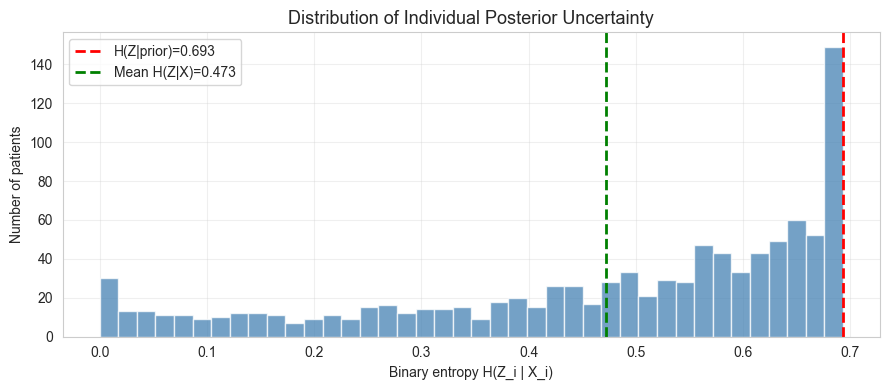

Patients with H(Z|X) near 0: data unambiguously classifies them.
Patients with H(Z|X) near log(2): features are ambiguous; model is uncertain.


In [4]:
# Summary computations: mutual information between X and Z
# I(X;Z) = H(Z) - H(Z|X) = H(Z) - sum_i p(Z=z)*H(X|Z=z) (discrete case)

# Approximate I(X_j; Z) via VI responsibilities
phi   = vi_result.responsibilities          # P(Z=1|X) per patient
H_Z   = -phi*np.log(phi+1e-12) - (1-phi)*np.log(1-phi+1e-12)  # binary entropy per patient
mean_H_Z = H_Z.mean()

# Prior entropy of Z from prevalence prior
prior_pi = config.alpha_hyper / (config.alpha_hyper + config.beta_hyper)
H_prior_Z = -prior_pi*np.log(prior_pi) - (1-prior_pi)*np.log(1-prior_pi)

print('Mutual Information Proxies')
print('=' * 45)
print(f'H(Z | prior pi):              {H_prior_Z:.4f} nats')
print(f'Mean H(Z | X, data):          {mean_H_Z:.4f} nats')
print(f'Approx I(Z; X) = H(Z) - H(Z|X): {H_prior_Z - mean_H_Z:.4f} nats')
print()

# Plot distribution of individual posterior entropies
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(H_Z, bins=40, color='steelblue', alpha=0.75, edgecolor='white')
ax.axvline(H_prior_Z, color='red', linestyle='--', linewidth=2, label=f'H(Z|prior)={H_prior_Z:.3f}')
ax.axvline(mean_H_Z,  color='green', linestyle='--', linewidth=2, label=f'Mean H(Z|X)={mean_H_Z:.3f}')
ax.set_xlabel('Binary entropy H(Z_i | X_i)')
ax.set_ylabel('Number of patients')
ax.set_title('Distribution of Individual Posterior Uncertainty', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/06_individual_entropy.png', dpi=120, bbox_inches='tight')
plt.show()

print('Patients with H(Z|X) near 0: data unambiguously classifies them.')
print('Patients with H(Z|X) near log(2): features are ambiguous; model is uncertain.')

## Summary

This notebook has synthesised the complete project along three axes:

### 1. Paradigm Influence
The Bayesian paradigm shaped every design decision: conjugate priors enabled analytical EM; hierarchical structure captured regional heterogeneity; posterior distributions gave direct probabilistic answers rather than point estimates. A frequentist treatment would have produced point estimates with asymptotic intervals but lacked the structural guidance that conjugacy provided.

### 2. Information Theory as Unifying Thread
KL divergence quantifies both the VI approximation error (as ELBO gap) and the information learned from data per region. Posterior entropy measures residual uncertainty. Mutual information quantifies feature diagnosticity. These concepts connect directly to the Shannon information-theoretic foundations of Bayesian updating: observing data reduces entropy in the posterior by exactly the amount of mutual information between data and latent variables.

### 3. Limitations and the Path Forward
The primary limitations are the Gaussian/independence assumptions on features, the absence of spatial structure, and the transductive nature of the inference. The proposed amortised neural-symbolic architecture addresses all three by: (a) using CNN encoders for raw image features, (b) preserving hierarchical structure as symbolic inductive bias, and (c) amortising inference across datasets. This represents a natural and well-motivated extension from classical probabilistic graphical models toward modern neural-symbolic AI.